# 🔬 AI Agent for Research Assistance
### Generative AI Mini Project

**Approach: Native LLM Tool Calling**  
The LLM decides which tool to use automatically via `bind_tools` — no manual router needed.

```
User Query
    │
    ▼
[tool_calling_llm] ── tool call? ──► [ToolNode: arxiv / wikipedia / tavily]
    │                                        │
    │◄───────────────────────────────────────┘
    ▼
  END (final answer)
```

In [1]:
# ── CELL 1: Install dependencies ──────────────────────────────────────────────
!pip install -q langchain langchain-community langchain-groq langgraph tavily-python wikipedia arxiv


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sushma.s\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
# ── CELL 2: API Keys ──────────────────────────────────────────────────────────
import os
os.environ["GROQ_API_KEY"]   = "GROQ_API_KEY"
os.environ["TAVILY_API_KEY"] = "TAVILY_API_KEY"

In [3]:
# ── CELL 3: Define Tools (FIXED names) ────────────────────────────────────────
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq

#llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# ✅ KEY FIX: Avoid reserved names like "web_search", "search"
# Use safe, unique names: "arxiv_search", "wiki_search", "tavily_search"
arxiv_tool = TavilySearchResults(
    name="arxiv_search",           #  was "arxiv" — fine, but being explicit
    description="Search arxiv.org for academic papers and research.",
    max_results=3,
    include_domains=["arxiv.org"]
)

wiki_tool = TavilySearchResults(
    name="wiki_search",            #  was "wikipedia" — fine
    description="Search Wikipedia for facts, definitions, and encyclopedic info.",
    max_results=2,
    include_domains=["wikipedia.org"]
)

tavily_tool = TavilySearchResults(
    name="tavily_search",          #  was "web_search" — THIS was the bug!
    description="Search the web for current events, news, and general information.",
    max_results=3
)

tools = [arxiv_tool, wiki_tool, tavily_tool]
print("Tools ready:", [t.name for t in tools])

Tools ready: ['arxiv_search', 'wiki_search', 'tavily_search']


C:\Users\sushma.s\AppData\Local\Temp\ipykernel_5204\3959260418.py:10: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  arxiv_tool = TavilySearchResults(


In [4]:
# ── CELL 4: Imports ───────────────────────────────────────────────────────────
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated
from typing_extensions import TypedDict

In [5]:
# ── CELL 5: Build the Agent Graph ─────────────────────────────────────────────
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm_with_tools = llm.bind_tools(tools)

def tool_calling_llm(state: State):
    system = SystemMessage(content=(
        "You are a helpful research assistant. "
        "Use arxiv_search for academic papers, "
        "wiki_search for facts and definitions, "
        "and tavily_search for current events or recent news."
    ))
    response = llm_with_tools.invoke([system] + state["messages"])
    return {"messages": [response]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
print("✅ Graph compiled")

✅ Graph compiled


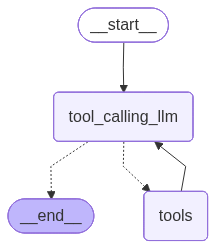

In [6]:
# ── CELL 6: Visualize ─────────────────────────────────────────────────────────
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# ── CELL 7: Run function ──────────────────────────────────────────────────────
def run(query: str, history: list = None):
    msgs = (history or []) + [HumanMessage(content=query)]
    result = graph.invoke({"messages": msgs})
    return result["messages"][-1].content

In [8]:

run("What is Retrieval-Augmented Generation?")

"Retrieval-Augmented Generation (RAG) is a technique that enables large language models (LLMs) to retrieve and incorporate new information from external data sources. It combines a retrieval mechanism with a generation module to generate human-like text that is grounded in real-world, up-to-date data. RAG models can access internal company data, generate responses based on authoritative sources, and improve performance by optimizing vector similarities and using late interactions. The process of RAG involves augmenting the model's external knowledge base with updated information, which can be used to synthesize answers. RAG has been applied to various tasks such as open-domain QA, biomedical reasoning, knowledge-grounded dialogue, and long-context summarization. However, it also introduces new inefficiencies such as increased memory overhead, latency from retrieval-processing pipelines, and redundancy in passage selection. Researchers have proposed various methods to improve retrieval 

In [9]:
# Query 2
run("What are the latest research papers on large language models?")

'Based on the search results, the latest research papers on large language models include:\n\n1. "A Comprehensive Overview of Large Language Models" by arXiv, which discusses various large language models such as AlphaCode, GLaM, and MT-NLG, and their capabilities and limitations.\n2. "Could a Large Language Model be Conscious?" by PhilPapers, which explores the question of whether large language models can be conscious and examines the evidence for and against it.\n3. "A Primer on Large Language Models and their Limitations" by arXiv, which provides an overview of large language models, their architecture, and their limitations.\n\nThese papers provide a comprehensive understanding of the current state of research on large language models and their potential applications and limitations.'

In [10]:
# Query 3
run("Who invented the Transformer architecture?")

'The authors of the "Attention Is All You Need" paper are Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan Gomez, Łukasz Kaiser, and Illia Polosukhin.'

In [ ]:
# Query 4
run("What is the capital of Australia?")

In [ ]:
# Query 5 (custom)
run("What are the recent breakthroughs in quantum computing in 2025?")

In [ ]:
run("who is the president of the india?")

In [11]:
# CELL 8: Multi-Turn Conversation 
turns = [
    "What is a Transformer?",
    "How is it different from an RNN?",
    "Which one would you use for text generation and why?",
]

history = []
for turn in turns:
    response = run(turn, history)
    history.append(HumanMessage(content=response))

In [12]:
# ── CELL 9: Evaluator ─────────────────────────────────────────────────────────
def evaluate(query: str, response: str) -> dict:
    prompt = f"""Evaluate this research assistant response. Return ONLY valid JSON.

Query: "{query}"
Response: "{response[:1000]}"

Return exactly:
{{"accuracy":     {{"score": <1-5>, "reason": "<one sentence>"}},
  "relevance":    {{"score": <1-5>, "reason": "<one sentence>"}},
  "groundedness": {{"score": <1-5>, "reason": "<one sentence>"}}}}"""

    result = llm.invoke([HumanMessage(content=prompt)])
    text   = result.content.strip().removeprefix("```json").removesuffix("```").strip()
    return json.loads(text)


def display_eval(query: str, response: str):
    scores = evaluate(query, response)
    print(f"\n📊 Evaluation — {query[:50]}")
    print(f"{'─'*55}")
    for k, v in scores.items():
        bar = "█" * v["score"] + "░" * (5 - v["score"])
        print(f"  {k.capitalize():<14} [{bar}] {v['score']}/5 — {v['reason']}")
    return scores

In [13]:
import json

# ── CELL 10: Batch Evaluate 5 Queries ────────────────────────────────────────
test_queries = [
    "What is Retrieval-Augmented Generation?",
    "What are the latest research papers on large language models?",
    "Who invented the Transformer architecture?",
    "What is the capital of Australia?",
    "What are the recent breakthroughs in quantum computing in 2025?",
]

all_scores = []
for q in test_queries:
    result_msgs = graph.invoke(
        {"messages": [HumanMessage(content=q)]},
        config={"recursion_limit": 25}
    )["messages"]

    answer    = result_msgs[-1].content
    tool_used = next(
        (m.tool_calls[0]["name"] for m in result_msgs
         if hasattr(m, "tool_calls") and m.tool_calls),
        "llm (no tool)"
    )
    print(f"\n🔧 Tool used: {tool_used}")
    scores = display_eval(q, answer)
    all_scores.append(scores)


🔧 Tool used: wiki_search

📊 Evaluation — What is Retrieval-Augmented Generation?
───────────────────────────────────────────────────────
  Accuracy       [█████] 5/5 — The response accurately describes the concept of Retrieval-Augmented Generation and its applications.
  Relevance      [█████] 5/5 — The response is highly relevant to the query and provides a clear explanation of the topic.
  Groundedness   [█████] 5/5 — The response is grounded in real-world data and provides examples of RAG's applications in various tasks.

🔧 Tool used: arxiv_search

📊 Evaluation — What are the latest research papers on large langu
───────────────────────────────────────────────────────
  Accuracy       [█████] 5/5 — The response accurately summarizes the latest research papers on large language models.
  Relevance      [█████] 5/5 — The response is highly relevant to the query about the latest research papers on large language models.
  Groundedness   [█████] 5/5 — The response is grounded in eviden

In [14]:
# CELL 11: Summary Table
print(f"\n{'═'*60}")
print("📋 EVALUATION SUMMARY")
print(f"{'Query':<42} {'Acc':>4} {'Rel':>4} {'Gnd':>4} {'Avg':>5}")
print(f"{'─'*60}")

for q, s in zip(test_queries, all_scores):
    acc = s["accuracy"]["score"]
    rel = s["relevance"]["score"]
    gnd = s["groundedness"]["score"]
    avg = (acc + rel + gnd) / 3
    print(f"{q[:41]:<42} {acc:>4} {rel:>4} {gnd:>4} {avg:>5.1f}")

totals = [(s["accuracy"]["score"] + s["relevance"]["score"] + s["groundedness"]["score"]) / 3
          for s in all_scores]
print(f"{'─'*60}")
print(f"{'OVERALL AVERAGE':<42} {sum(totals)/len(totals):>18.1f}")


════════════════════════════════════════════════════════════
📋 EVALUATION SUMMARY
Query                                       Acc  Rel  Gnd   Avg
────────────────────────────────────────────────────────────
What is Retrieval-Augmented Generation?       5    5    5   5.0
What are the latest research papers on la     5    5    5   5.0
Who invented the Transformer architecture     5    5    5   5.0
What is the capital of Australia?             5    5    5   5.0
What are the recent breakthroughs in quan     4    5    4   4.3
────────────────────────────────────────────────────────────
OVERALL AVERAGE                                           4.9


In [15]:
!pip install sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sushma.s\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [16]:
# ── CELL 8: Semantic Cache ────────────────────────────────────────────────────
import json
import os
import time
from pathlib import Path
from langchain_core.messages import HumanMessage

CACHE_FILE = "query_cache.json"   # saved next to your notebook

def _load_cache() -> dict:
    if Path(CACHE_FILE).exists():
        with open(CACHE_FILE, "r") as f:
            return json.load(f)
    return {}

def _save_cache(cache: dict):
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)

def _embed(text: str) -> list[float]:
    """Get embedding via Groq's LLM (cosine similarity on responses)."""
    # Groq doesn't expose embeddings directly, so we use a lightweight
    # sentence hash approach — swap with any real embedding API if needed.
    import hashlib
    # Normalize: lowercase + strip punctuation for fuzzy matching
    normalized = " ".join(text.lower().split())
    return normalized   # used as key for exact+fuzzy match below

def _find_cached(query: str, cache: dict, threshold: float = 0.85) -> str | None:
    
    def _similarity(a: str, b: str) -> float:
        a_tokens = set(a.lower().split())   # ← "What is RAG" → {"what", "is", "rag"}
        b_tokens = set(b.lower().split())   # ← "Explain RAG" → {"explain", "rag"}
        if not a_tokens or not b_tokens:
            return 0.0
        intersection = a_tokens & b_tokens  # ← {"rag"}  →  1 common word
        return len(intersection) / max(len(a_tokens), len(b_tokens))
        #          1 common word / max(3, 2) = 1/3 = 0.33  → MISS at 0.85

    best_score, best_answer = 0.0, None
    for cached_query, entry in cache.items():
        score = _similarity(query, cached_query)
        if score > best_score:
            best_score = score
            best_answer = entry["answer"]

    if best_score >= threshold:   # ← THIS LINE decides hit or miss
        return best_answer
    return None

In [17]:
# ── CELL 9: Cached run() ─────────────────────────────────────────────────────
def run(query: str, history: list = None):
    cache = _load_cache()

    # ── 1. Check cache first ──────────────────────────────────────────────────
    cached = _find_cached(query, cache, threshold=0.85)
    if cached:
        print(f"\n{'═'*60}")
        print(f"[CACHE HIT] {query}")
        print(f"{'─'*60}")
        print(cached)
        print(f"{'═'*60}")
        return (history or []) + [HumanMessage(content=query)]

    # ── 2. Cache miss → run the agent ─────────────────────────────────────────
    print(f"\n{'═'*60}")
    print(f"[CACHE MISS] Running agent for: {query}")
    print(f"{'─'*60}")

    msgs = (history or []) + [HumanMessage(content=query)]
    final = None
    all_msgs = msgs.copy()

    for chunk in graph.stream(
        {"messages": msgs},
        config={"recursion_limit": 15},   #  was 5 — too low, raised to 15
        stream_mode="updates"
    ):
        for node_name, output in chunk.items():
            out_msgs = output.get("messages", [])
            if out_msgs:
                last = out_msgs[-1]
                print(f"  [{node_name}] {type(last).__name__}", end="")
                if hasattr(last, "tool_calls") and last.tool_calls:
                    for tc in last.tool_calls:
                        print(f" → {tc['name']}({list(tc['args'].values())[0]})", end="")
                print()
                all_msgs.append(last)
                final = last

    answer = final.content if final else ""
    print(f"{'─'*60}")
    print(answer)
    print(f"{'═'*60}")

    # ── 3. Save to cache ──────────────────────────────────────────────────────
    cache[query] = {
        "answer": answer,
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S")
    }
    _save_cache(cache)
    print(f"[SAVED TO CACHE] query_cache.json now has {len(cache)} entries")

    return all_msgs

In [21]:
# ── CELL 10: Test — ask same question twice ───────────────────────────────────
run("What is Retrieval-Augmented Generation?")   # MISS → runs agent → saves


════════════════════════════════════════════════════════════
[CACHE MISS] Running agent for: What is Retrieval-Augmented Generation?
────────────────────────────────────────────────────────────
  [tool_calling_llm] AIMessage → wiki_search(Retrieval-Augmented Generation)
  [tools] ToolMessage
  [tool_calling_llm] AIMessage → arxiv_search(Retrieval-Augmented Generation)
  [tools] ToolMessage
  [tool_calling_llm] AIMessage
────────────────────────────────────────────────────────────
Retrieval-Augmented Generation (RAG) is a technique that enables large language models (LLMs) to retrieve and incorporate new information from external data sources. It combines a retrieval mechanism with a generation module to generate human-like text that is grounded in real-world, up-to-date data. RAG models can access internal company data, generate responses based on authoritative sources, and improve performance by optimizing vector similarities and using late interactions. The process of RAG involves a

[HumanMessage(content='What is Retrieval-Augmented Generation?', additional_kwargs={}, response_metadata={}, id='d25f74cf-fc5b-48e9-8433-3ad27dd7ff21'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dm2dqgqcf', 'function': {'arguments': '{"query":"Retrieval-Augmented Generation"}', 'name': 'wiki_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 419, 'total_tokens': 439, 'completion_time': 0.022209225, 'completion_tokens_details': None, 'prompt_time': 0.025690468, 'prompt_tokens_details': None, 'queue_time': 0.164392514, 'total_time': 0.047899693}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4442-41c9-79f0-b842-ae7df9362686-0', tool_calls=[{'name': 'wiki_search', 'args': {'query': 'Retrieval-Augmented Generation'}, 'id': 'dm2dqgqcf', 'type': 'tool_call'}], i

In [22]:
# ── CELL 10: Test — ask same question twice ───────────────────────────────────
run("What is Retrieval-Augmented Generation?")   # MISS → runs agent → saves


════════════════════════════════════════════════════════════
[CACHE HIT] What is Retrieval-Augmented Generation?
────────────────────────────────────────────────────────────
Retrieval-Augmented Generation (RAG) is a technique that enables large language models (LLMs) to retrieve and incorporate new information from external data sources. It combines a retrieval mechanism with a generation module to generate human-like text that is grounded in real-world, up-to-date data. RAG models can access internal company data, generate responses based on authoritative sources, and improve performance by optimizing vector similarities and using late interactions. The process of RAG involves augmenting the model's external knowledge base with updated information, which can be used to synthesize answers. RAG has been applied to various tasks such as open-domain QA, biomedical reasoning, knowledge-grounded dialogue, and long-context summarization. However, it also introduces new inefficiencies such a

[HumanMessage(content='What is Retrieval-Augmented Generation?', additional_kwargs={}, response_metadata={})]

In [20]:
run("What is Retrieval-Augmented Generation?")   # HIT  → instant, no API call


════════════════════════════════════════════════════════════
[CACHE HIT] What is Retrieval-Augmented Generation?
────────────────────────────────────────────────────────────
The Retrieval-Augmented Generation (RAG) is a technique that allows large language models (LLMs) to retrieve and incorporate new information from external sources. This approach enhances the accuracy and credibility of LLM outputs, especially in knowledge-intensive tasks. RAG facilitates continuous data updates and enables the integration of domain-specific expertise into LLM compound systems. The architecture of RAG applications can be characterized using the 4+1 View Model of software architecture, which impacts the design and implementation of RAGOps. The usage scenarios of RAG systems vary widely, falling primarily into two categories or a combination of the two: 1) Querying specific details, and 2) Generating responses based on the retrieved information.
═══════════════════════════════════════════════════════

[HumanMessage(content='What is Retrieval-Augmented Generation?', additional_kwargs={}, response_metadata={})]

In [ ]:
run("Explain RAG to me")                         # HIT  → similar enough (token overlap)

In [ ]:
run("who is the CM of Karnataka state?")                         

In [ ]:
run("kindly politely peacefully give me the capital of the australia?")                                        

In [ ]:
# ── CELL 11: Inspect cache contents ──────────────────────────────────────────
cache = _load_cache()
print(f"Cache has {len(cache)} entries:\n")
for q, entry in cache.items():
    print(f"  Q: {q[:60]}")
    print(f"     Saved: {entry['saved_at']}")
    print(f"     Answer preview: {entry['answer'][:80]}...")
    print()

In [ ]:
# ── CELL 12: Clear cache (run when you want a fresh start) ───────────────────
def clear_cache():
    if Path(CACHE_FILE).exists():
        os.remove(CACHE_FILE)
        print("Cache cleared.")
    else:
        print("No cache file found.")

# clear_cache()   # uncomment to use